In [1]:
import pandas as pd
import anndata as ad
import scanpy as sc
import numpy as np

import os
import sys

import seaborn as sns
import seaborn.objects as so
import matplotlib.pyplot as plt
from plotnine import *
from tqdm import tqdm
from scipy.stats import anderson_ksamp, false_discovery_control

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import logging

os.chdir("/g/stegle/schrod/code/TCell")
from utils import *

logging.basicConfig(format="[%(asctime)s] %(levelname)s:%(name)s: %(message)s", stream=sys.stdout)
logger = logging.getLogger(__name__)
logger.setLevel(logging.INFO)


def qq_plot(p_values_dict, title=None, cutoff=None, samples = None, save_path=None):
    """
    Draws a combined QQ plot for multiple datasets.
    
    Parameters
    ----------
    p_values_dict : dict
        Dictionary with dataset names as keys and p-value arrays as values.
    title : str
        Plot title.
    """
    plt.figure(figsize=(8, 8))
    
    colors = ['steelblue', 'coral', 'seagreen', 'purple']
    markers = ['o', 's', '^', 'D']
    
    max_expected = 0
    
    for i, (name, p_values) in enumerate(p_values_dict.items()):
        if samples is not None:
            p_values = np.random.choice(p_values, size=samples, replace=False)
        p_values = np.array(p_values)
        p_values = p_values[~np.isnan(p_values)]  # remove NaNs
        p_values = p_values[(p_values > 0) & (p_values <= 1)]  # valid range
        
        if len(p_values) == 0:
            logger.warning(f"No valid p-values for {name}")
            continue
        
        # Expected quantiles under uniform(0,1) null
        n = len(p_values)
        expected = -np.log10(np.linspace(1/(n+1), n/(n+1), n))
        
        # Observed quantiles
        observed = -np.log10(np.sort(p_values))
        
        if cutoff is not None:
            observed[observed > cutoff] = cutoff
   
        
        # Plot with different colors and markers
        color = colors[i % len(colors)]
        marker = markers[i % len(markers)]
        plt.scatter(expected, observed, s=15, edgecolor='none', alpha=0.6, 
                   color=color, marker=marker, label=f'{name} (n={len(p_values):,})')
        
        max_expected = max(max_expected, max(expected))
    
    # y=x line
    plt.plot([0, max_expected], [0, max_expected], color='red', linestyle='--', 
            linewidth=2, label='Expected (uniform)')
    
    plt.xlabel("Expected -log10(p)", fontsize=12)
    plt.ylabel("Observed -log10(p)", fontsize=12)
    if title is not None:
        plt.title(title, fontsize=13, fontweight='bold')
    plt.legend(loc='upper left', fontsize=10)
    if cutoff is not None:
        plt.xlim(0, cutoff)
        plt.ylim(0, cutoff)
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path)
        logger.info(f"Saved QQ plot to {save_path}")
    plt.show()


In [2]:

DEG_results_path_pb = "/g/stegle/schrod/code/TCell/pseudobulk_deseq2_NT_ribosomal"
logger.info(f"Load pseudobulk DESeq2 results from: {DEG_results_path_pb}")
df_nt = load_deg_results(DEG_results_path_pb, pval_threshold=None)

[2026-02-20 13:05:33,550] INFO:__main__: Load pseudobulk DESeq2 results from: /g/stegle/schrod/code/TCell/pseudobulk_deseq2_NT_ribosomal


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 173/173 [00:03<00:00, 43.90it/s]


In [3]:
# Remove NAs before plotting
df_nt = df_nt.dropna()

In [4]:
df_nt_sig = df_nt[df_nt["adj_p_value"] < 0.1].copy()
print("Number of significant hits (pval<0.1):", df_nt_sig.shape[0])
print("total number of tests:", df_nt.shape[0])
print(f"Fraction of significant hits: {df_nt_sig.shape[0] / df_nt.shape[0]:.4f}")
df_nt_sig.variable.value_counts()


Number of significant hits (pval<0.1): 215
total number of tests: 1382310
Fraction of significant hits: 0.0002


variable
HILPDA       3
RNASEH2C     3
HIST1H2AC    3
GZMA         2
SOX12        2
            ..
BMPR2        1
CD2AP        1
FUBP1        1
AIF1         1
CTSW         1
Name: count, Length: 201, dtype: int64

In [5]:
745/2408301*100000

30.934671372058556

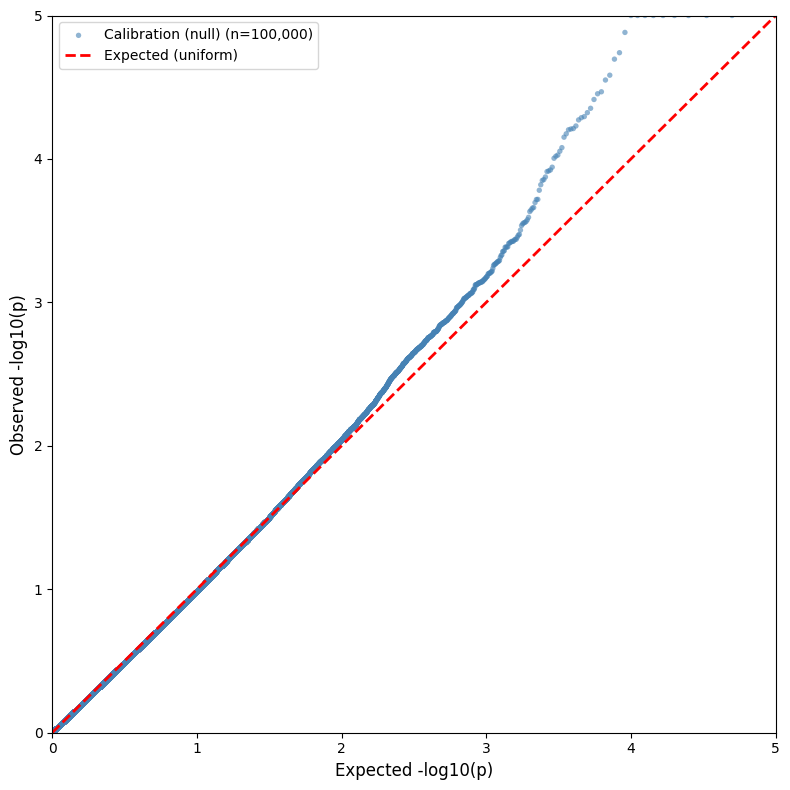

In [6]:

qq_plot({'Calibration (null)': df_nt['p_value'].values}, cutoff=5, samples = 100000)


In [7]:
DEG_results_path = "/g/stegle/schrod/code/TCell/pseudobulk_deseq2_chunks50_min3bulks_ribosomal"
logger.info(f"Load pseudobulk DESeq2 results from: {DEG_results_path}")
df_DESeq = load_deg_results(DEG_results_path, pval_threshold=None)  

[2026-02-20 13:05:38,389] INFO:__main__: Load pseudobulk DESeq2 results from: /g/stegle/schrod/code/TCell/pseudobulk_deseq2_chunks50_min3bulks_ribosomal


  0%|                                                                                                                                      | 0/146 [00:00<?, ?it/s]

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 146/146 [00:55<00:00,  2.65it/s]


In [8]:
df_DESeq_sig = df_DESeq[df_DESeq["adj_p_value"] < 0.1].copy()
print("Number of significant hits (pval<0.1):", df_DESeq_sig.shape[0])
print("total number of tests:", df_DESeq.shape[0])
print(f"Fraction of significant hits: {df_DESeq_sig.shape[0] / df_DESeq.shape[0]:.4f}")
df_DESeq_sig.variable.value_counts()

Number of significant hits (pval<0.1): 96762
total number of tests: 58407300
Fraction of significant hits: 0.0017


variable
MDM2      147
RPS19     131
RPS27L    124
TPT1      121
HSPA1B    118
         ... 
TNXB        1
ZNF671      1
CAPN10      1
PRPF18      1
CCL3L1      1
Name: count, Length: 7618, dtype: int64

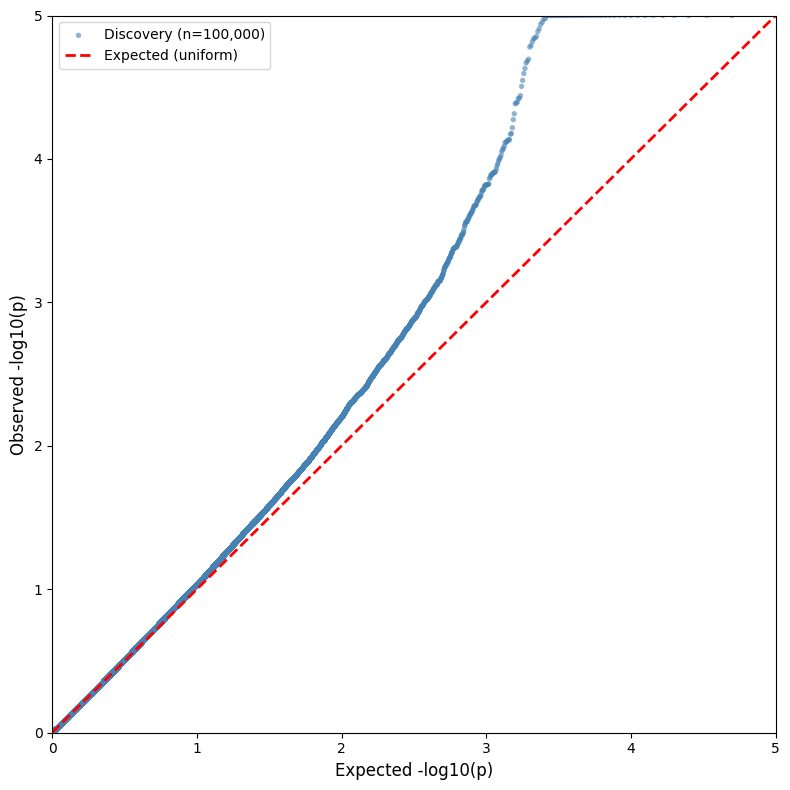

In [9]:
# subsample to 1000000 points for better visualization
df_DESeq_sub = df_DESeq.sample(n=1000000, random_state=42)
qq_plot({'Discovery': df_DESeq_sub['p_value'].values}, cutoff=5, samples = 100000)


[2026-02-20 13:27:11,269] INFO:__main__: Saved QQ plot to /g/stegle/schrod/code/TCell/plots/final/QQ_plot_NT_calibration_vs_discovery.pdf


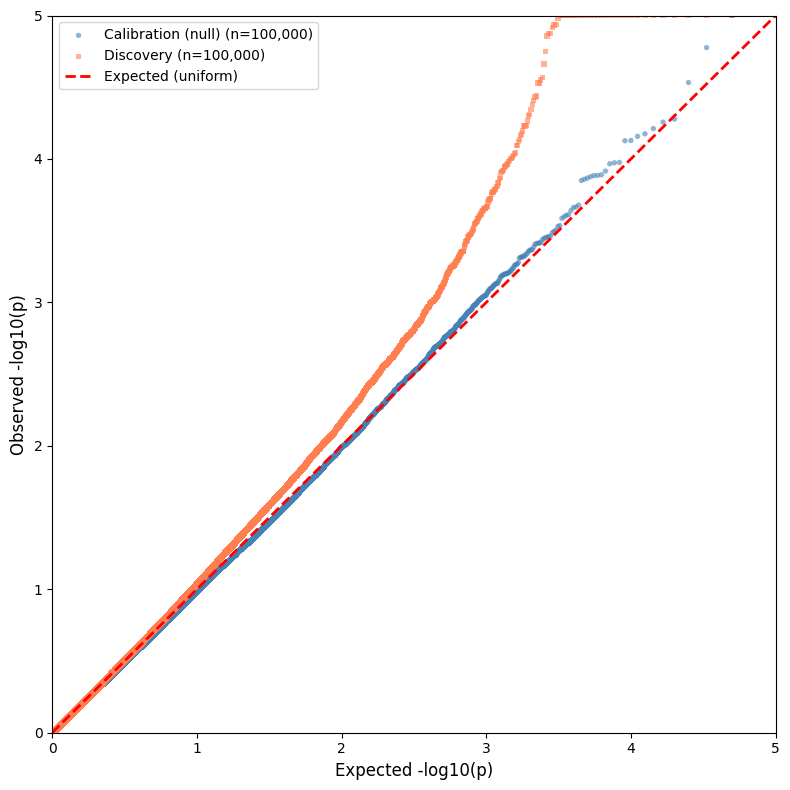

In [13]:



p_values_dict = {
    'Calibration (null)': df_nt['p_value'].values,
    'Discovery': df_DESeq['p_value'].values
}
np.random.seed(42)
qq_plot(p_values_dict, cutoff=5, samples = 100000, save_path="/g/stegle/schrod/code/TCell/plots/final/QQ_plot_NT_calibration_vs_discovery.pdf")


[2026-02-20 13:07:06,788] INFO:__main__: Saved QQ plot to /g/stegle/schrod/code/TCell/plots/final/QQ_plot_NT_calibration_vs_discovery.pdf


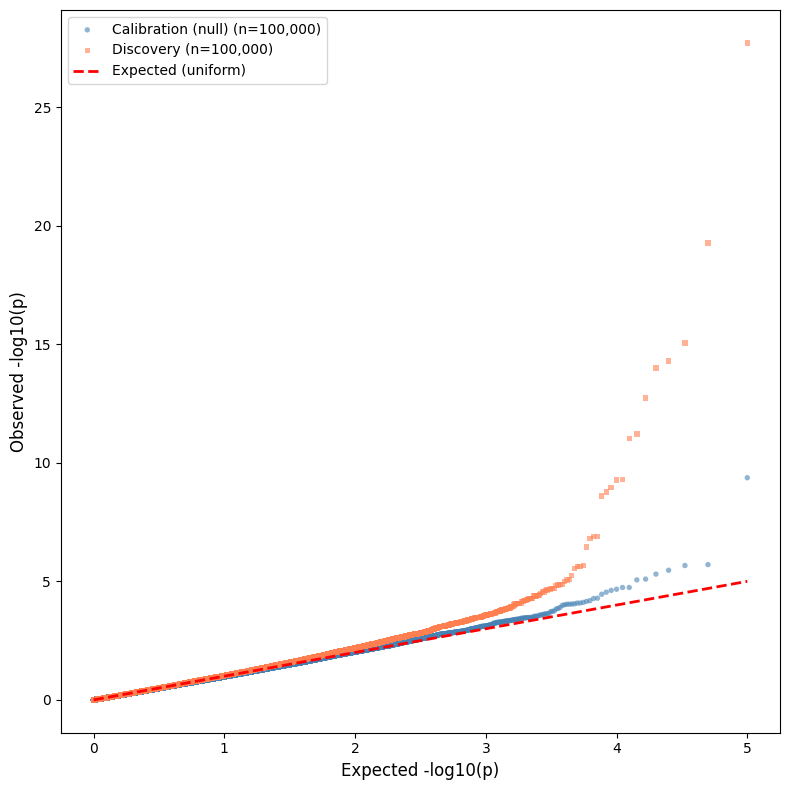

In [12]:
qq_plot(p_values_dict, samples = 100000, save_path="/g/stegle/schrod/code/TCell/plots/final/QQ_plot_NT_calibration_vs_discovery.pdf")
